# Example of a full processing workflow for Slocum glider AD2CP data

- This notebook is an separate iteration to calculate and output an error estimate for the least-squares velocity fit

## Imports

In [1]:
# Imports
import numpy as np
import pandas as pd
import glob
import datetime
import xarray as xr
import gsw
import matplotlib.pyplot as plt
from datetime import datetime
import dask.array as da
import slocum_ad2cp


## Step 1: Load Glider Data

In [2]:
ds_id = 'ru29-20240419T1430-trajectory-raw-delayed'

## Load flight data
variables = ['depth', 'latitude', 'longitude', 'time','source_file', 'm_water_vx', 'm_water_vy', 'm_heading','m_gps_mag_var']
gdf = slocum_ad2cp.get_erddap_dataset(ds_id, server='http://slocum-data.marine.rutgers.edu/erddap', variables = variables, filetype='dataframe')
gdf.columns = variables

## Great way to find start and end times!!
start_times = gdf.groupby('source_file').first().time.values
end_times   = gdf.groupby('source_file').last().time.values
## Remove time zone for slicing ad2cp times
start_times2 = pd.to_datetime(start_times).tz_localize(None)
end_times2 = pd.to_datetime(end_times).tz_localize(None)
gdf['time'] = pd.to_datetime(gdf.time)
## Convert magnetic variation and heading to degrees
gdf['m_gps_mag_var'] = np.rad2deg(gdf['m_gps_mag_var'].values)
gdf['m_heading'] = np.rad2deg(gdf['m_heading'].values)
## Correct heading for magnetic variation
gdf['m_heading'] = gdf.m_heading-np.nanmean(gdf.m_gps_mag_var)

gdf

,depth,latitude,longitude,time,source_file,m_water_vx,m_water_vy,m_heading,m_gps_mag_var
0,0.000000,17.779262,-67.057948,2024-04-19 14:30:28+00:00,ru29-2024-109-2-0-dbd(06930000),NaN,NaN,NaN,NaN
1,NaN,17.779262,-67.057948,2024-04-19 14:30:31+00:00,ru29-2024-109-2-0-dbd(06930000),0.0,0.0,130.305985,12.40001
2,0.000000,17.779262,-67.057948,2024-04-19 14:30:32+00:00,ru29-2024-109-2-0-dbd(06930000),NaN,NaN,NaN,NaN
3,NaN,17.779262,-67.057948,2024-04-19 14:31:29+00:00,ru29-2024-109-2-0-dbd(06930000),0.0,0.0,130.305985,12.40001
4,NaN,17.779350,-67.057945,2024-04-19 14:31:49+00:00,ru29-2024-109-2-0-dbd(06930000),NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7446400,0.099413,15.649022,-68.998793,2024-07-02 09:09:13+00:00,ru29-2024-182-1-9-dbd(07060009),NaN,NaN,NaN,NaN
7446401,0.089471,15.649022,-68.998793,2024-07-02 09:09:15+00:00,ru29-2024-182-1-9-dbd(07060009),NaN,NaN,NaN,NaN
7446402,-0.049706,15.649022,-68.998793,2024-07-02 09:09:17+00:00,ru29-2024-182-1-9-dbd(07060009),NaN,NaN,NaN,NaN
7446403,-0.019883,15.649022,-68.998793,2024-07-02 09:09:19+00:00,ru29-2024-182-1-9-dbd(07060009),NaN,NaN,NaN,NaN


## Step 2: Load in AD2CP data frame

In [3]:
path='../data/ad2cp/'
files = np.sort(glob.glob(path+'*.nc'))
tot_ad2cp = slocum_ad2cp.load_ad2cp(files,mean_lat=15)
tot_ad2cp

/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/slocum_ad2cp/make_dataset.py:857: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_mfdataset(
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/slocum_ad2cp/make_dataset.py:857: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_mfdataset(
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/slocum_ad2cp/make_dataset.py:857: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_mfdataset(
/Users/joegra

<xarray.Dataset> Size: 1GB
Dimensions:                    (time: 1152490, VelocityRange: 15,
                                CorrelationRange: 15, AmplitudeRange: 15,
                                Physicalbeam_dim: 4)
Coordinates:
  * time                       (time) datetime64[ns] 9MB 2024-04-19T14:32:13....
  * VelocityRange              (VelocityRange) float32 60B 2.2 4.2 ... 28.2 30.2
  * CorrelationRange           (CorrelationRange) float32 60B 2.2 4.2 ... 30.2
  * AmplitudeRange             (AmplitudeRange) float32 60B 2.2 4.2 ... 30.2
Dimensions without coordinates: Physicalbeam_dim
Data variables: (12/43)
    VelocityBeam1              (VelocityRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    VelocityBeam2              (VelocityRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    VelocityBeam3              (VelocityRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    VelocityBeam4              (VelocityRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    CorrelationBeam1           (CorrelationRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    CorrelationBeam2           (CorrelationRange, time) float32 69MB dask.array<chunksize=(15, 80990), meta=np.ndarray>
    ...                         ...
    EnsembleCount              (time) float64 9MB dask.array<chunksize=(80990,), meta=np.ndarray>
    WaterTemperature           (time) float32 5MB dask.array<chunksize=(80990,), meta=np.ndarray>
    Heading                    (time) float32 5MB dask.array<chunksize=(80990,), meta=np.ndarray>
    Pitch                      (time) float32 5MB dask.array<chunksize=(80990,), meta=np.ndarray>
    Roll                       (time) float32 5MB dask.array<chunksize=(80990,), meta=np.ndarray>
    Depth                      (time) float64 9MB 0.85 0.9305 ... 0.8251 0.8928
Attributes: (12/350)
    instrumentOffsetTimeMatlab_description:       Offset from instrument time...
    File_ins_runTime:                             442996000.0
    File_ins_runTime_description:                 Length of time data was col...
    File_ins_name:                                AD2CPRaw
    File_ins_name_description:                    Name of instrument
    File_ins_typeName:                            
    ...                                           ...
    instrumentOffsetTime:                         0.0
    instrumentOffsetTime_description:             Offset from instrument time...
    timeZoneOffset:                               0
    timeZoneOffset_description:                   Offset of platform local ti...
    instrumentOffsetTimeMatlab:                   0.0
    exportRevision:                               4489

## Step 3: Soft Iron Magnetic Correction (pitch-dependent)
Best to do this on the entire dataset first

In [4]:
tot_ad2cp = slocum_ad2cp.correct_ad2cp_heading(tot_ad2cp)

/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/slocum_ad2cp/make_dataset.py:963: RuntimeWarning: invalid value encountered in sqrt
  radii = np.sqrt(1. / evals)
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/slocum_ad2cp/make_dataset.py:1098: RuntimeWarning: invalid value encountered in multiply
  CorrectedHeading = np.empty_like(head) * np.nan


In [14]:

def inversion2(U,V,dz,u_daverage,v_daverage,bins,depth, wDAC, wSmoothness):
    global O_ls, G_ls, bin_new

    ## Feb-2021 jgradone@marine.rutgers.edu Initial
    ## Jul-2021 jgradone@marine.rutgers.edu Updates for constraints
    ## Jun-2022 jgradone@marine.rutgers.edu Corrected dimensions and indexing of G matrix
    ## Jun-2022 jgradone@marine.rutgers.edu Added curvature minimizing constraint and constraint weights

    ## Purpose: Take velocity measurements from glider mounted ADCP and compute
    # shear profiles

    ## Outputs:
    # O_ls is the ocean velocity profile
    # G_ls is the glider velocity profile
    # bin_new are the bin centers for the point in the profiles
    # obs_per_bin is the number of good velocity observations per final profile bin

    ## Inputs:
    # dz is desired vertical resolution, should not be smaller than bin length 
    # U is measured east-west velocities from ADCP
    # V is measured north-south velocities from ADCP
    # bins is the bin depths for the U and V measurements
    # uv_daverage is depth averaged velocity (Set to 0 for real-time)
    # depth is the depth of the glider measured by the ADCP
    # wDAC is the weight of the DAC constraint (5 per Todd et al. 2017)
    # wSmoothness is the weight of the curvature minimizing contraint (1 per Todd et al. 2017)


    #########################################################################  
    ## These steps filter for NAN rows and columns so they are technically QAQC
    ## but I think the best place to put them is inthe inversion function because
    ## if there are nans still present in the data here, it will throw everything off
    ## These steps are HUGE for efficiency because it reduces the size of the G
    ## matrix as much as possible.

    ## This determines the rows (bins) where all the columns are nan
    nanind = np.where( (np.sum(np.isnan(U),axis=1)/U.shape[1]) == 1)[0]
    if len(nanind) > 0:
        U = np.delete(U,nanind,axis=0)
        V = np.delete(V,nanind,axis=0)
        bins = np.delete(bins,nanind)

    ## Do the same thing with individual ensembles. Note: need to remove the corresponding
    ## ensemble pressure reading to ensure correction dimensions and values.
    nanind = np.where((np.sum(np.isnan(U),axis=0)/U.shape[0]) == 1)[0]
    if len(nanind) > 0:
        U = np.delete(U,nanind,axis=1)
        V = np.delete(V,nanind,axis=1)
        depth = np.delete(depth,nanind)
    ##########################################################################        


    ##########################################################################        
    # Take difference between bin lengths for bin size [m]
    bin_size = np.diff(bins)[0]
    bin_num = len(bins)
    # This creates a grid of the ACTUAL depths of the ADCP bins by adding the
    # depths of the ADCP bins to the actual depth of the instrument
    [bdepth,bbins]=np.meshgrid(depth,bins)
    bin_depth = bdepth+bbins  
    Z = bin_depth
    # Calculate the maximum depth of glider which is different than maximum ADCP bin depth
    ZmM = np.nanmax(depth)
    ##########################################################################        


    ##########################################################################        
    # Set knowns from Equations 19 from Visbeck (2002) page 800
    # Maximum number of observations (nd) is given by the number of velocity
    # estimates per ping (nbin) times the number of profiles per cast (nt)
    nbin = U.shape[0]  # number of programmed ADCP bins per individual profile
    nt   = U.shape[1]  # number of individual velocity profiles
    nd   = nbin*nt      # G dimension (1) 

    # Define the edges of the bins
    bin_edges = np.arange(0,math.floor(np.max(bin_depth)),dz).tolist()

    # Check that each bin has data in it
    bin_count = np.empty(len(bin_edges)-1) # Preallocate memory
    bin_count[:] = np.nan

    for k in np.arange(len(bin_edges))[:-1]:
        # Create index of depth values that fall inside the bin edges
        ii = np.where((bin_depth > bin_edges[k]) & (bin_depth < bin_edges[k+1]))
        bin_count[k] = len(bin_depth[ii])
        ii = []

    # Create list of bin centers    
    bin_new = [x+dz/2 for x in bin_edges[:-1]]

    # Calculate which FINAL solution bin is deeper than the maximum depth of the glider
    # This is done so that the depth averaged velocity constraint is only applied to bins shallower than this depth
    depth_ind = len(np.where(bin_new>ZmM)[0])
    # Chop off the top of profile if no data
    ind = np.argmax(bin_count > 0) # Stops at first index greater than 0
    bin_new = bin_new[ind:]        # Removes all bins above first with data
    z1 = bin_new[0]                # Depth of center of first bin with data
    ##########################################################################        


    ##########################################################################        
    # Create and populate G
    nz = len(bin_new)  # number of ocean velocities desired in output profile
    nm = nt + nz       # G dimension (2), number of unknowns
    # Let's build the corresponding coefficient matrix G 
    G = scipy.sparse.lil_matrix((nd, nm), dtype=float)

    # Indexing of the G matrix was taken from Todd et al. 2012
    for ii in np.arange(0,nt):           # Number of ADCP ensembles per segment
        for jj in np.arange(0,nbin):     # Number of measured bins per ensemble 

            # Uctd part of matrix
            G[(nbin*(ii))+jj,ii] = -1
            # This will fill in the Uocean part of the matrix. It loops through
            # all Z members and places them in the proper location in the G matrix
            # Find the difference between all bin centers and the current Z value        
            dx = abs(bin_new-Z[jj,ii])
            # Find the minimum of these differences
            minx = np.nanmin(dx)
            # Finds bin_new index of the first match of Z and bin_new    
            idx = np.argmin(dx-minx)

            # Uocean part of matrix
            G[(nbin*(ii))+jj,(nt)+idx] = 1

            del dx, minx, idx

    ##########################################################################        
    # Reshape U and V into the format of the d column vector (order='F')
    # Based on how G is made, d needs to be ensembles stacked on one another vertically
    d_u = U.flatten(order='F')
    d_v = V.flatten(order='F')

    ##########################################################################
    ## This chunk of code containts the constraints for depth averaged currents
    # Make sure the constraint is only applied to the final ocean velocity bins that the glider dives through
    # Don't apply it to the first bin and don't apply it to the bins below the gliders dive depth
    constraint = np.concatenate(([np.zeros(nt)], [0], [np.tile(dz,nz-(1+depth_ind))], [np.zeros(depth_ind)]), axis=None)

    # Ensure the L^2 norm of the constraint equation is unity
    constraint_norm = np.linalg.norm(constraint/ZmM)
    C = 1/constraint_norm
    constraint_normalized = (C/ZmM)*constraint ## This is now equal to 1 (unity)
    # Build Gstar and add weight from todd 2017
    ## Some smarts would be to calculate signal to noise ratio first
    Gstar = scipy.sparse.vstack((G,wDAC*constraint_normalized), dtype=float)


    # Add the constraint for the depth averaged velocity from Todd et al. (2017)
    du = np.concatenate(([d_u],[wDAC*C*u_daverage]), axis=None)
    dv = np.concatenate(([d_v],[wDAC*C*v_daverage]), axis=None)
    d = np.array(list(map(complex,du, dv)))


    ##########################################################################        
    #### THIS removes all nan elements of d AND Gstar so the inversion doesn't blow up with nans
    ind2 = np.where(np.isnan(d)==True)[0]
    d = np.delete(d,ind2)

    def delete_rows_csr(mat, indices):
        """
        Remove the rows denoted by ``indices`` form the CSR sparse matrix ``mat``.
        """
        if not isinstance(mat, scipy.sparse.csr_matrix):
            raise ValueError("works only for CSR format -- use .tocsr() first")
        indices = list(indices)
        mask = np.ones(mat.shape[0], dtype=bool)
        mask[indices] = False
        return mat[mask]

    Gstar = delete_rows_csr(Gstar.tocsr().copy(),ind2)

    #########################################################################        
    # Test adding depth for tracking bin location
    # d is ensembles stacked on one another vertically so same for Z (order='F')
    Z_filt = Z.flatten(order='F')
    Z_filt = np.delete(Z_filt,ind2)
    Z_filt = np.concatenate(([Z_filt],[0]), axis=None)

    ##########################################################################        
    ## Calculation the number of observations per bin
    obs_per_bin = np.empty(len(bin_new))
    obs_per_bin[:] = np.nan

    for x in np.arange(0,nz):
        rows_where_nt_not_equal_zero = np.where(Gstar.tocsr()[0:Z_filt.shape[0],nt+x].toarray() > 0 )[0]
        obs_per_bin[x] = len(rows_where_nt_not_equal_zero)

    ## If there is no data in the last bin, drop that from the G matrix, bin_new, and obs_per_bin
    if obs_per_bin[-1] == 0:
        Gstar.tocsr()[:,:-1]
        bin_new = bin_new[:-1]
        obs_per_bin = obs_per_bin[:-1]
        ## Update nz and nt
        nz = len(bin_new)
        nt = Gstar.shape[1]-nz

    ##########################################################################        
    ## Smoothness constraint
    ## Only do this is the smoothness constraint is set
    if wSmoothness > 0:
        ## Add a vector of zerosm the length of nz, twice to the bottom of the data column vector
        d = np.concatenate(([d],[np.zeros(nz)],[np.zeros(nz)]), axis=None)
        ## Constraint on smoothing Uocean side of matrix
        smoothing_matrix_Uocean = scipy.sparse.diags([[-1],[2],[-1]], [0,1,2], shape=(nz,nz))
        smoothing_matrix1 = scipy.sparse.hstack((np.zeros((nz,nt)),smoothing_matrix_Uocean), dtype=float)
        ## Constraint on smoothing Uglider side of matrix
        smoothing_matrix_Uglider = scipy.sparse.diags([[-1],[2],[-1]], [0,1,2], shape=(nz,nt))
        smoothing_matrix2 = scipy.sparse.hstack((smoothing_matrix_Uglider,np.zeros((nz,nz))), dtype=float)
        Gstar = scipy.sparse.vstack((Gstar,wSmoothness*smoothing_matrix1,wSmoothness*smoothing_matrix2), dtype=float)


    ##########################################################################        
    ## Run the Least-Squares Inversion!
    x = lsqr(Gstar, d)[0]

    O_ls = x[nt:]
    G_ls = x[0:nt] 
    ########################################################################## 
    # After lsqr
    GtG = (Gstar.conj().T @ Gstar)
    Cx = scipy.sparse.linalg.inv(GtG)

    # Optional scaling
    r = Gstar @ x - d
    sigma2 = np.real(np.vdot(r, r)) / (len(d) - len(x))
    Cx = sigma2 * Cx

    C_O = Cx[nt:, nt:]
    sigma_O = np.sqrt(C_O.diagonal())


    return(O_ls, G_ls, bin_new, obs_per_bin, sigma_O)


## Steps 4-11: Big loop to process velocity data and save output

In [ ]:
#for x in range(0,len(start_times)):


x=501

## Subset glider df to one segment
subsetgdf = gdf[(gdf.time >= start_times[x]) & (gdf.time <= end_times[x])]

ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()

if len(ind)>0:
    ## Pull out last non-NaN lat/lon    
    vx          = subsetgdf.m_water_vx.iloc[ind[-1]]
    vy          = subsetgdf.m_water_vy.iloc[ind[-1]]
    mag_var     = np.nanmean(subsetgdf.m_gps_mag_var) ## mean over the whole segment for this one because it only changes at the surface
    vx_start_lon = subsetgdf.longitude.iloc[ind[0]]
    vx_start_lat = subsetgdf.latitude.iloc[ind[0]]
    vx_end_lon   = subsetgdf.longitude.iloc[ind[-1]]
    vx_end_lat   = subsetgdf.latitude.iloc[ind[-1]]
    vx_start_tm = subsetgdf.time.iloc[0]
    vx_end_tm   = subsetgdf.time.iloc[-1]
    
        
ad2cp_time_ind = np.where((tot_ad2cp.time.values >= start_times2[x]) & (tot_ad2cp.time.values <= end_times2[x]))[0]

subset_ad2cp = tot_ad2cp.sel(time= slice(tot_ad2cp.time.values[ad2cp_time_ind[0]],tot_ad2cp.time.values[ad2cp_time_ind[-1]]))

# Just check if there is still data after the subsetting         
# Pre-process data before inversion

## Correct DAC for local magnetic declination
_,vx_cor,vy_cor= slocum_ad2cp.mag_var_correction(subsetgdf['m_heading'].values,vx,vy,mag_var)
## Correct AD2CP heading for local magnetic declination
subset_ad2cp= slocum_ad2cp.mag_var_correction_ad2cp_ds(subset_ad2cp, heading_var="CorrectedHeading", mag_var_arr=mag_var)
## Correct for local speed of sound
subset_ad2cp = slocum_ad2cp.correct_sound_speed(subset_ad2cp)
## QAQC pre-coordinate transformation
subset_ad2cp = slocum_ad2cp.qaqc_pre_coord_transform(subset_ad2cp, corr_threshold = 50, max_amplitude = 75)
## Correct beams to level true-depth
subset_ad2cp = slocum_ad2cp.beam_true_depth(subset_ad2cp)
## Bin map
subset_ad2cp = slocum_ad2cp.binmap_adcp(subset_ad2cp)
## AHRS rotation matrix
subset_ad2cp = slocum_ad2cp.calcAHRS(subset_ad2cp)
## Beam to ENU
subset_ad2cp = slocum_ad2cp.beam2enu(subset_ad2cp)
## QAQC post-coordinate transformation
subset_ad2cp = slocum_ad2cp.qaqc_post_coord_transform(subset_ad2cp, high_velocity_threshold=0.75, surface_depth_to_filter = 5)

## Now ready for inversion!
dz=10            
wDAC = 5
wSmoothness = 1
O_ls, G_ls, bin_new, obs_per_bin, sigma_O = inversion2(subset_ad2cp.UVelocity.values,subset_ad2cp.VVelocity.values,
                                                            dz,vx_cor,vy_cor,subset_ad2cp['VelocityRange'].values,subset_ad2cp['Depth'].values, wDAC, wSmoothness)

###############################################
#             Save master dataset             #
###############################################

## Make into a dataframe to save as a CSV
d = {'inversion_u': np.real(O_ls), 'inversion_v': np.imag(O_ls), "inversion_depth": bin_new,
        "start_lon": np.tile(vx_start_lon,len(bin_new)), "start_lat": np.tile(vx_start_lat,len(bin_new)),
        "end_lon": np.tile(vx_end_lon,len(bin_new)), "end_lat": np.tile(vx_end_lat,len(bin_new)),
        "start_tm": np.tile(vx_start_tm, len(bin_new)), "end_tm": np.tile(vx_end_tm, len(bin_new)),
        "obs_per_bin": obs_per_bin}


df = pd.DataFrame(data=d)


/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/3390460287.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


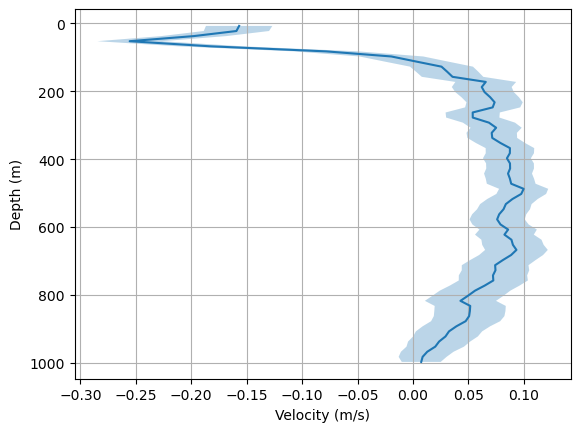

In [30]:
fig, ax = plt.subplots()
ax.plot(np.real(O_ls), bin_new, label='U')
ax.fill_betweenx(bin_new,
                 np.real(O_ls)-sigma_O,
                 np.real(O_ls)+sigma_O,
                 alpha=0.3)
ax.invert_yaxis()
ax.set_xlabel('Velocity (m/s)')
ax.set_ylabel('Depth (m)')

plt.grid()

In [33]:
for x in range(0,len(start_times)):

    ## Subset glider df to one segment
    subsetgdf = gdf[(gdf.time >= start_times[x]) & (gdf.time <= end_times[x])]
    
    ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()
    
    if len(ind)>0:
        ## Pull out last non-NaN lat/lon    
        vx          = subsetgdf.m_water_vx.iloc[ind[-1]]
        vy          = subsetgdf.m_water_vy.iloc[ind[-1]]
        mag_var     = np.nanmean(subsetgdf.m_gps_mag_var) ## mean over the whole segment for this one because it only changes at the surface
        vx_start_lon = subsetgdf.longitude.iloc[ind[0]]
        vx_start_lat = subsetgdf.latitude.iloc[ind[0]]
        vx_end_lon   = subsetgdf.longitude.iloc[ind[-1]]
        vx_end_lat   = subsetgdf.latitude.iloc[ind[-1]]
        vx_start_tm = subsetgdf.time.iloc[0]
        vx_end_tm   = subsetgdf.time.iloc[-1]
        
    if subsetgdf.depth.max() < 10:
            continue
            
    ad2cp_time_ind = np.where((tot_ad2cp.time.values >= start_times2[x]) & (tot_ad2cp.time.values <= end_times2[x]))[0]
    if len(ad2cp_time_ind) > 0:

        subset_ad2cp = tot_ad2cp.sel(time= slice(tot_ad2cp.time.values[ad2cp_time_ind[0]],tot_ad2cp.time.values[ad2cp_time_ind[-1]]))

        # Just check if there is still data after the subsetting 
        if len(subset_ad2cp.time) > 0:
            
            # Pre-process data before inversion

            ## Correct DAC for local magnetic declination
            _,vx_cor,vy_cor= slocum_ad2cp.mag_var_correction(subsetgdf['m_heading'].values,vx,vy,mag_var)
            ## Correct AD2CP heading for local magnetic declination
            subset_ad2cp= slocum_ad2cp.mag_var_correction_ad2cp_ds(subset_ad2cp, heading_var="CorrectedHeading", mag_var_arr=mag_var)
            ## Correct for local speed of sound
            subset_ad2cp = slocum_ad2cp.correct_sound_speed(subset_ad2cp)
            ## QAQC pre-coordinate transformation
            subset_ad2cp = slocum_ad2cp.qaqc_pre_coord_transform(subset_ad2cp, corr_threshold = 50, max_amplitude = 75)
            ## Correct beams to level true-depth
            subset_ad2cp = slocum_ad2cp.beam_true_depth(subset_ad2cp)
            ## Bin map
            subset_ad2cp = slocum_ad2cp.binmap_adcp(subset_ad2cp)
            ## AHRS rotation matrix
            subset_ad2cp = slocum_ad2cp.calcAHRS(subset_ad2cp)
            ## Beam to ENU
            subset_ad2cp = slocum_ad2cp.beam2enu(subset_ad2cp)
            ## QAQC post-coordinate transformation
            subset_ad2cp = slocum_ad2cp.qaqc_post_coord_transform(subset_ad2cp, high_velocity_threshold=0.75, surface_depth_to_filter = 5)
            
            ## Now ready for inversion!
            dz=10            
            wDAC = 5
            wSmoothness = 1
            O_ls, G_ls, bin_new, obs_per_bin, sigma_O = inversion2(subset_ad2cp.UVelocity.values,subset_ad2cp.VVelocity.values,
                                                                      dz,vx_cor,vy_cor,subset_ad2cp['VelocityRange'].values,subset_ad2cp['Depth'].values, wDAC, wSmoothness)
            now = datetime.now().strftime("%m/%d/%y %H:%M:%S")
            print("Finished Inversion", x ,"out of",len(start_times),"at" ,now)

            ###############################################
            #             Save master dataset             #
            ###############################################
            fname = "../data/ad2cp_csv_test/RU29_2024_AD2CP_Processed_Segment_"+str(x)+".csv".format(dz,x)

            ## Make into a dataframe to save as a CSV
            d = {'inversion_u': np.real(O_ls), 'inversion_v': np.imag(O_ls), "inversion_depth": bin_new,
                 "start_lon": np.tile(vx_start_lon,len(bin_new)), "start_lat": np.tile(vx_start_lat,len(bin_new)),
                 "end_lon": np.tile(vx_end_lon,len(bin_new)), "end_lat": np.tile(vx_end_lat,len(bin_new)),
                 "start_tm": np.tile(vx_start_tm, len(bin_new)), "end_tm": np.tile(vx_end_tm, len(bin_new)),
                 "obs_per_bin": obs_per_bin, "sigma_O": sigma_O}


            df = pd.DataFrame(data=d)
            df.to_csv(fname,index=False) 
            now = datetime.now().strftime("%m/%d/%y %H:%M:%S")
            print("Finished Writing Data", x ,"out of",len(start_times),"at" ,now)
            del subset_ad2cp
            
        else:
            del subset_ad2cp
            

/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array ins

Finished Inversion 0 out of 1345 at 01/06/26 14:43:49
Finished Writing Data 0 out of 1345 at 01/06/26 14:43:49


/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()


Finished Inversion 1 out of 1345 at 01/06/26 14:43:51
Finished Writing Data 1 out of 1345 at 01/06/26 14:43:51


/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


...

/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Finished Inversion 1000 out of 1345 at 01/06/26 15:32:27
Finished Writing Data 1000 out of 1345 at 01/06/26 15:32:27


/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/joegradone/anaconda3/envs/RU29_69W/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Finished Inversion 1014 out of 1345 at 01/06/26 15:32:33
Finished Writing Data 1014 out of 1345 at 01/06/26 15:32:33


/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2869833361.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ind         = np.argwhere(np.isnan(subsetgdf.m_water_vx).ravel()==False).flatten()


## Load in pre-processed data

In [34]:
path ='../data/ad2cp_csv_test/'
fname='../data/processed_nc/RU29_2024_Processed_AD2CP_test.nc'
files = np.sort(glob.glob(path+'*.csv'))
df = pd.concat(map(pd.read_csv, files))

inversion_dz = np.diff(df.inversion_depth)[0].astype(int)
inversion_depth         = np.arange(np.min(df.inversion_depth),np.max(df.inversion_depth)+inversion_dz,inversion_dz)
inversion_time          = np.empty(len(files))
inversion_time[:]       = np.nan
inversion_time          = inversion_time.astype(pd.Timestamp)
inversion_start_time    = np.empty(len(files))
inversion_start_time[:] = np.nan
inversion_start_time    = inversion_time.astype(pd.Timestamp)
inversion_end_time      = np.empty(len(files))
inversion_end_time[:]   = np.nan
inversion_end_time      = inversion_time.astype(pd.Timestamp)
inversion_lat           = np.empty(len(files))
inversion_lat[:]        = np.nan
inversion_lon           = np.empty(len(files))
inversion_lon[:]        = np.nan
inversion_start_lat     = np.empty(len(files))
inversion_start_lat[:]  = np.nan
inversion_start_lon     = np.empty(len(files))
inversion_start_lon[:]  = np.nan
inversion_end_lat       = np.empty(len(files))
inversion_end_lat[:]    = np.nan
inversion_end_lon       = np.empty(len(files))
inversion_end_lon[:]    = np.nan
u_grid = np.empty((len(inversion_depth),len(files)))
u_grid[:] = np.nan
v_grid = np.empty((len(inversion_depth),len(files)))
v_grid[:] = np.nan
num_obs = np.empty((len(inversion_depth),len(files)))
num_obs[:] = np.nan
uncertainty = np.empty((len(inversion_depth),len(files)))
uncertainty[:] = np.nan


## Loop through by file, load in each file
for x in np.arange(0,len(files)):
    
    df = pd.read_csv(files[x])
    
    u_grid[np.arange(0,len(df.inversion_u.values)),x] = df.inversion_u.values
    v_grid[np.arange(0,len(df.inversion_v.values)),x] = df.inversion_v.values
    num_obs[np.arange(0,len(df.inversion_u.values)),x] = df.obs_per_bin.values
    uncertainty[np.arange(0,len(df.inversion_u.values)),x] = df.sigma_O.values
    
    inversion_start_time[x] = pd.to_datetime(df.start_tm[0]).tz_localize(None)
    inversion_end_time[x] = pd.to_datetime(df.end_tm[0]).tz_localize(None)
    mid_time = inversion_end_time[x]-inversion_start_time[x]
    
    inversion_time[x] = inversion_start_time[x]+mid_time

    inversion_start_lat[x] = df.start_lat[0]
    inversion_start_lon[x] = df.start_lon[0]
    inversion_end_lat[x]   = df.end_lat[0]
    inversion_end_lon[x]   = df.end_lon[0]
    ## Lat/lon mid point
    inversion_lat[x]   = (df.start_lat[0]+df.end_lat[0])/2
    inversion_lon[x]   = (df.start_lon[0]+df.end_lon[0])/2


    
## Now stuff into an organized xarray dataset    
ds = xr.Dataset(
    data_vars=dict(
        u_grid     = (["depth", "time"], u_grid),
        v_grid     = (["depth", "time"], v_grid),
        num_obs    = (["depth", "time"], num_obs),
        uncertainty= (["depth", "time"], uncertainty),
        latitude   = (["time"], inversion_lat),
        longitude  = (["time"], inversion_lon),
        start_lat  = (["time"], inversion_start_lat),
        start_lon  = (["time"], inversion_start_lon),
        end_lat    = (["time"], inversion_end_lat),
        end_lon    = (["time"], inversion_end_lon),
        start_time = (["time"], inversion_start_time),
        end_time   = (["time"], inversion_end_time)
    ),
    coords=dict(
        time  = inversion_time,
        depth = inversion_depth
    ),
    attrs=dict(description="RU29 Nortek AD2CP least-squares inversion velocity profile dataset \nG. Unger Vetlesen Foundation Funded Challenger Mission: ABC2DR Line\nhttps://slocum-data.marine.rutgers.edu/erddap/tabledap/ru29-20240419T1430-trajectory-raw-delayed.html"),
)

## Sort by time because files may not have in read in chronological order
ds = ds.sortby(ds.time)
#save output to netcdf
ds.to_netcdf(fname)
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (depth: 100, time: 486)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2024-04-19T14:50:04 ... 2024-06-30...
  * depth        (depth) float64 800B 5.0 15.0 25.0 35.0 ... 975.0 985.0 995.0
Data variables:
    u_grid       (depth, time) float64 389kB -0.04912 0.03099 ... nan nan
    v_grid       (depth, time) float64 389kB 0.05382 -0.01673 ... nan nan
    num_obs      (depth, time) float64 389kB 3.0 2.0 2.0 1.0 ... nan nan nan nan
    uncertainty  (depth, time) float64 389kB 0.01789 0.02302 0.02363 ... nan nan
    latitude     (time) float64 4kB 17.78 17.78 17.78 ... 16.13 16.13 16.13
    longitude    (time) float64 4kB -67.06 -67.07 -67.08 ... -69.0 -69.0 -69.0
    start_lat    (time) float64 4kB 17.78 17.78 17.78 ... 16.13 16.13 16.13
    start_lon    (time) float64 4kB -67.06 -67.06 -67.07 ... -69.0 -69.0 -69.0
    end_lat      (time) float64 4kB 17.78 17.78 17.78 ... 16.13 16.13 16.13
    end_lon      (time) float64 4kB -67.06 -67.07 -67.09 ... -69.0 -69.0 -69.0
    start_time   (time) datetime64[ns] 4kB 2024-04-19T14:30:28 ... 2024-06-30...
    end_time     (time) datetime64[ns] 4kB 2024-04-19T14:50:04 ... 2024-06-30...
Attributes:
    description:  RU29 Nortek AD2CP least-squares inversion velocity profile ...

(1000.0, 0.0)

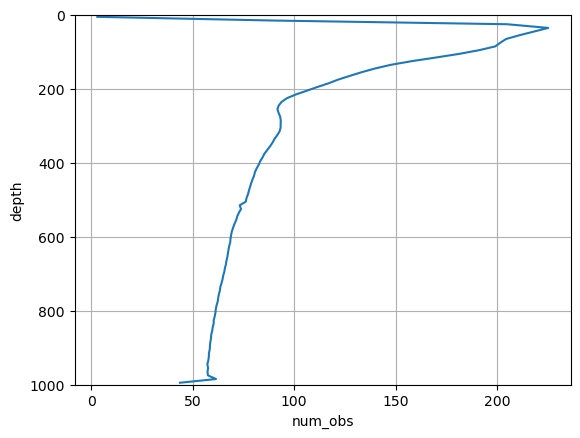

In [43]:
ds.num_obs.mean(dim='time').plot(y='depth')
plt.grid()
plt.ylim(1000,0)

In [46]:
## Taken from RU29_ABC2DR_Analysis.ipynb
transect1_start_time = pd.to_datetime('2024-04-27T20:05:00Z').tz_localize(None) ## transect 1 start time
transect1_end_time = pd.to_datetime('2024-05-18T12:00:00Z').tz_localize(None) ## transect 1 end time
transect2_start_time = pd.to_datetime('2024-05-19T00:00:00Z').tz_localize(None) ## transect 2 start time
transect2_end_time = pd.to_datetime('2024-06-06T00:00:00Z').tz_localize(None) ## transect 2 end time

transect1 = ds.sel(time=slice(transect1_start_time,transect1_end_time))
transect2 = ds.sel(time=slice(transect2_start_time,transect2_end_time))



In [47]:
def median_latitude_binned_transect(
    ds: xr.Dataset,
    lat_step_km: float,
    lat_name: str = 'latitude',
    depth_name: str = 'depth',
    u_name: str = 'u_grid',
    v_name: str = 'v_grid'
) -> xr.Dataset:
    """
    Bin data along latitude in fixed physical intervals and compute the median
    u and v velocity at each depth.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset containing u_grid and v_grid
    lat_step_km : float
        Latitude bin size in kilometers
    lat_name : str
        Name of latitude coordinate
    depth_name : str
        Name of depth coordinate
    u_name : str
        Name of u velocity variable
    v_name : str
        Name of v velocity variable

    Returns
    -------
    xr.Dataset
        Dataset containing median_u_grid and median_v_grid on a regular latitude grid
    """

    # --- Latitude grid ---
    min_lat = ds[lat_name].min().item()
    max_lat = ds[lat_name].max().item()

    lat_step_deg = lat_step_km / 111.32  # km → degrees
    lat_grid = np.arange(min_lat, max_lat + lat_step_deg, lat_step_deg)

    depth = ds[depth_name].values

    # --- Allocate output arrays ---
    median_u = np.full((len(depth), len(lat_grid) - 1), np.nan)
    median_v = np.full((len(depth), len(lat_grid) - 1), np.nan)
    median_uncertainty = np.full((len(depth), len(lat_grid) - 1), np.nan)

    lat_vals = ds[lat_name].values

    # --- Loop through bins and depth ---
    for y in range(len(lat_grid) - 1):
        lat_min = lat_grid[y]
        lat_max = lat_grid[y + 1]

        for x in range(len(depth)):
            lat_inds = np.where(
                (lat_vals >= lat_min) & (lat_vals < lat_max)
            )[0]

            if lat_inds.size > 0:
                median_u[x, y] = np.nanmedian(ds[u_name].isel({depth_name: x}).values[lat_inds])
                median_v[x, y] = np.nanmedian(ds[v_name].isel({depth_name: x}).values[lat_inds])
                median_uncertainty[x, y] = np.median(ds['uncertainty'].isel({depth_name: x}).values[lat_inds])

    # --- Build output Dataset ---
    lat_center = 0.5 * (lat_grid[:-1] + lat_grid[1:])

    ds_out = xr.Dataset(
        data_vars={
            'median_u_grid': ([depth_name, lat_name], median_u),
            'median_v_grid': ([depth_name, lat_name], median_v),
            'median_uncertainty': ([depth_name, lat_name], median_uncertainty),
            
        },
        coords={
            depth_name: depth,
            lat_name: lat_center,
        },
        attrs={
            'comment': f'Median-binned velocities in {lat_step_km:.1f} km latitude bins'
        }
    )

    return ds_out

lat_step_km = 6  # km

transect1_median = median_latitude_binned_transect(transect1, lat_step_km=lat_step_km)
transect2_median = median_latitude_binned_transect(transect2, lat_step_km=lat_step_km)
transect2_median

/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2607547741.py:61: RuntimeWarning: All-NaN slice encountered
  median_u[x, y] = np.nanmedian(ds[u_name].isel({depth_name: x}).values[lat_inds])
/var/folders/m9/d8bbz1wx4f50q99kfb1jv9pw0000gn/T/ipykernel_68102/2607547741.py:62: RuntimeWarning: All-NaN slice encountered
  median_v[x, y] = np.nanmedian(ds[v_name].isel({depth_name: x}).values[lat_inds])


<xarray.Dataset> Size: 225kB
Dimensions:             (depth: 100, latitude: 93)
Coordinates:
  * depth               (depth) float64 800B 5.0 15.0 25.0 ... 975.0 985.0 995.0
  * latitude            (latitude) float64 744B 12.76 12.81 ... 17.66 17.72
Data variables:
    median_u_grid       (depth, latitude) float64 74kB 0.02741 ... -0.009948
    median_v_grid       (depth, latitude) float64 74kB 0.06872 ... 0.002242
    median_uncertainty  (depth, latitude) float64 74kB 0.0303 ... 0.01516
Attributes:
    comment:  Median-binned velocities in 6.0 km latitude bins

In [63]:

def calc_cell_transport(ds,lat_step_km,u_var='median_u_grid',uncertainty_var='median_uncertainty'):
    dz = np.diff(ds.depth)[0]
    segment_dist = lat_step_km*1000  # convert to meters
    
    segment_transport = np.empty(ds[u_var].shape)
    segment_transport[:] = np.nan
    segment_transport_uncertainty = np.empty(ds[uncertainty_var].shape)
    segment_transport_uncertainty[:] = np.nan

    for x in np.arange(0,len(ds.latitude)):
        for z in np.arange(0,len(ds.depth)):
            segment_transport[z,x] = ds[u_var][z,x]*segment_dist*dz
            segment_transport_uncertainty[z,x] = ds[uncertainty_var][z,x]*segment_dist*dz
    
    ds["cell_transport"] = (("depth","latitude"), segment_transport)
    ds["cell_transport_uncertainty"] = (("depth","latitude"), segment_transport_uncertainty)
    return ds

In [64]:
transect1_median = calc_cell_transport(transect1_median, lat_step_km=lat_step_km, u_var='median_u_grid')
transect2_median = calc_cell_transport(transect2_median, lat_step_km=lat_step_km, u_var='median_u_grid')

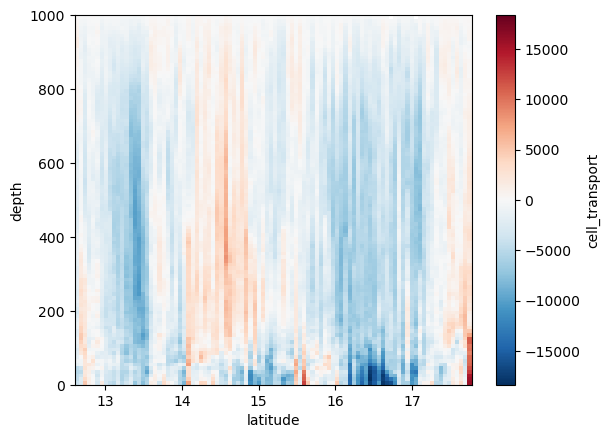

In [65]:
transect1_median.cell_transport.plot(y='depth')

In [68]:
transect1_median.cell_transport.sum()/(10**6)

<xarray.DataArray 'cell_transport' ()> Size: 8B
array(-17.35556432)

In [ ]:
transect1_median.cell_transport_uncertainty.sum()/(10**6)

<xarray.DataArray 'cell_transport_uncertainty' ()> Size: 8B
array(17.3035783)

In [71]:
test = np.empty(transect1_median.cell_transport.shape)
test[:] = 0.01

np.sum(test*6000*10)/(10**6)

5.76

Text(0.5, 0, 'Uncertainty (m/s)')

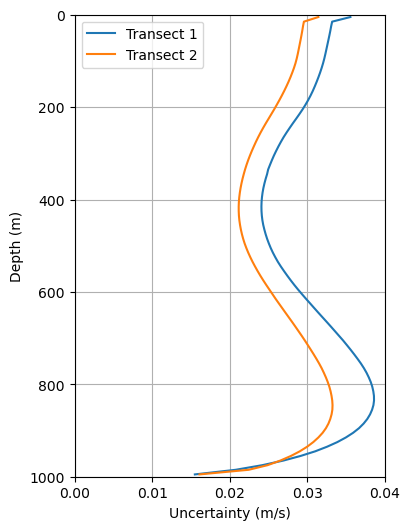

In [94]:
plt.figure(figsize=(4,6))
plt.plot(transect1_median.median_uncertainty.mean(dim='latitude'),transect1_median.depth,label='Transect 1')#.plot(y='depth')
plt.plot(transect2_median.median_uncertainty.mean(dim='latitude'),transect2_median.depth,label='Transect 2')#.plot(y='depth')
plt.legend()
plt.grid()
plt.ylim(1000,0)
plt.xlim(0,0.04)
plt.ylabel('Depth (m)')
plt.xlabel('Uncertainty (m/s)')
